# IRPEF comunale 2019-2023 — validazione dati

Notebook tecnico. Genera le figure per il README e verifica i trend della capacita fiscale.

**Dataset**: `irpef_comunale` (MEF) via GCS clean parquet.
**Serie**: 2019-2023, 5 anni, ~7900 comuni.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
GCS = 'gs://dataciviclab-clean/irpef_comunale/*/irpef_comunale_*_clean.parquet'

# Verifica copertura
anni = con.execute(f"SELECT DISTINCT anno_di_imposta FROM read_parquet('{GCS}') ORDER BY anno_di_imposta").fetchdf()
print(f"Anni: {list(anni['anno_di_imposta'])}")


Anni: [2019, 2020, 2021, 2022, 2023]


In [2]:
# 1. Trend nazionale 2019-2023
trend = con.execute(f"""
    SELECT anno_di_imposta AS anno,
           CAST(SUM(numero_contribuenti) AS BIGINT) AS contribuenti,
           CAST(SUM(reddito_imponibile_eur) AS BIGINT) AS imponibile,
           CAST(SUM(imposta_netta_eur) AS BIGINT) AS imposta,
           ROUND(CAST(SUM(reddito_imponibile_eur) AS DOUBLE)
                 / NULLIF(CAST(SUM(numero_contribuenti) AS DOUBLE), 0), 0) AS media_imponibile
    FROM read_parquet('{GCS}')
    GROUP BY anno_di_imposta
    ORDER BY anno_di_imposta
""").fetchdf()

display(trend)

print(f"Contribuenti: {int(trend[trend['anno']==2019]['contribuenti'].values[0]):,} -> {int(trend[trend['anno']==2023]['contribuenti'].values[0]):,}")
print(f"Media imponibile: {int(trend[trend['anno']==2019]['media_imponibile'].values[0]):,}EUR -> {int(trend[trend['anno']==2023]['media_imponibile'].values[0]):,}EUR")


,anno,contribuenti,imponibile,imposta,media_imponibile
0,2019,41525982,833645714315,165116802240,"20,075"
1,2020,41180529,815214668955,159281005023,"19,796"
2,2021,41497318,860860376820,170993284167,"20,745"
3,2022,42026960,914153289796,174201434957,"21,752"
4,2023,42570078,968183215110,189939932938,"22,743"


Contribuenti: 41,525,982 -> 42,570,078
Media imponibile: 20,075EUR -> 22,743EUR


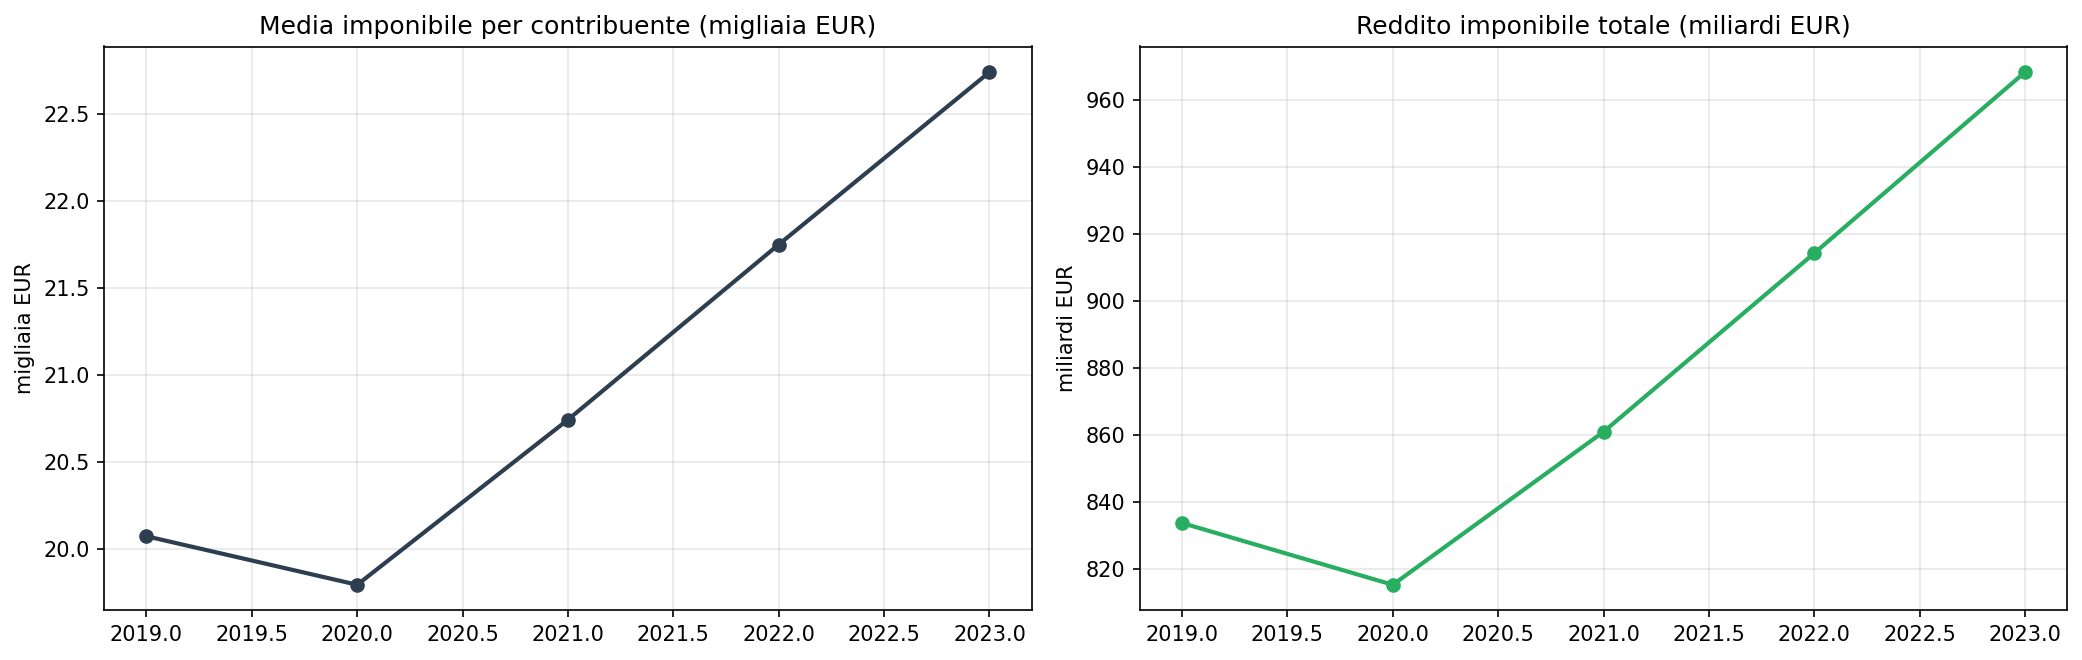

Salvato: figures/irpef_trend_nazionale.png


In [3]:
# Grafico trend nazionale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(trend['anno'], trend['media_imponibile'] / 1000, marker='o', linewidth=2, color='#2c3e50')
ax1.set_title('Media imponibile per contribuente (migliaia EUR)', fontsize=12)
ax1.set_ylabel('migliaia EUR')
ax1.grid(alpha=0.3)

ax2.plot(trend['anno'], trend['imponibile'] / 1e9, marker='o', linewidth=2, color='#27ae60')
ax2.set_title('Reddito imponibile totale (miliardi EUR)', fontsize=12)
ax2.set_ylabel('miliardi EUR')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/irpef_trend_nazionale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/irpef_trend_nazionale.png')


In [4]:
# 2. Classifica regioni 2023
regioni = con.execute(f"""
    SELECT regione,
           CAST(SUM(numero_contribuenti) AS BIGINT) AS contribuenti,
           CAST(SUM(reddito_imponibile_eur) AS BIGINT) AS imponibile,
           ROUND(CAST(SUM(reddito_imponibile_eur) AS DOUBLE)
                 / NULLIF(CAST(SUM(numero_contribuenti) AS DOUBLE), 0), 0) AS media_imponibile,
           ROUND(CAST(SUM(imposta_netta_eur) AS DOUBLE)
                 / NULLIF(CAST(SUM(reddito_imponibile_eur) AS DOUBLE), 0) * 100, 1) AS aliquota_effettiva_pct
    FROM read_parquet('{GCS}')
    WHERE anno_di_imposta = 2023 AND regione != 'Mancante/errata'
    GROUP BY regione
    ORDER BY media_imponibile DESC
""").fetchdf()

display(regioni)

media_nord = int(regioni[regioni['regione'].isin(['Lombardia', 'Trentino Alto Adige(P.A.Bolzano)', 'Emilia Romagna', 'Piemonte', 'Veneto', 'Liguria', 'Friuli Venezia Giulia', 'Valle d\'Aosta'])]['media_imponibile'].mean())
media_sud = int(regioni[regioni['regione'].isin(['Campania', 'Puglia', 'Basilicata', 'Calabria', 'Sicilia', 'Sardegna', 'Molise', 'Abruzzo'])]['media_imponibile'].mean())
print(f"Media Nord: {media_nord:,} EUR")
print(f"Media Sud: {media_sud:,} EUR")
print(f"Divario: {media_nord - media_sud:,} EUR ({((media_nord - media_sud) / media_sud * 100):.0f}%)")


,regione,contribuenti,imponibile,media_imponibile,aliquota_effettiva_pct
0,Lombardia,7542193,201598099350,"26,729",22
1,Trentino Alto Adige(P.A.Bolzano),447058,11782198777,"26,355",21
2,Emilia Romagna,3499851,86591268968,"24,741",20
3,Lazio,4019025,97805613962,"24,336",21
4,Valle d'Aosta,99231,2399277819,"24,179",20
5,Piemonte,3239693,77857995084,"24,033",20
6,Trentino Alto Adige(P.A.Trento),443328,10607820958,"23,928",19
7,Veneto,3766133,89647361564,"23,804",19
8,Friuli Venezia Giulia,955028,22730090570,"23,800",19
9,Liguria,1199819,27959886847,"23,303",20


Media Nord: 24,618 EUR
Media Sud: 18,517 EUR
Divario: 6,101 EUR (33%)


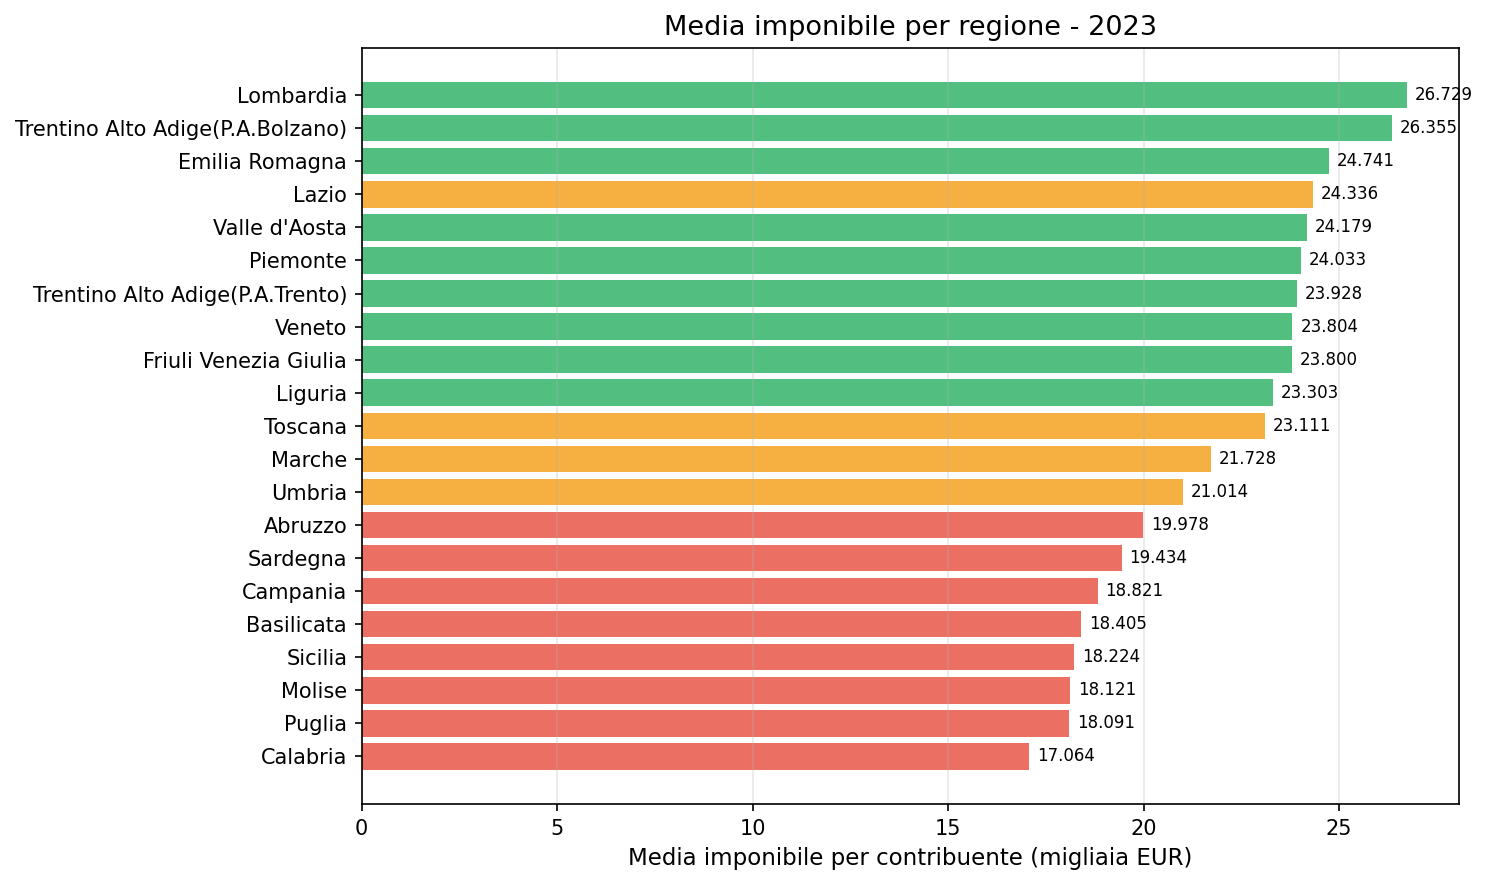

Salvato: figures/irpef_regioni_2023.png


In [5]:
# Grafico regioni 2023
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = regioni.sort_values('media_imponibile')
colors = ['#e74c3c' if r in ['Campania','Puglia','Basilicata','Calabria','Sicilia','Sardegna','Molise','Abruzzo']
          else '#27ae60' if r in ['Lombardia','Emilia Romagna','Veneto','Piemonte','Trentino Alto Adige(P.A.Bolzano)','Trentino Alto Adige(P.A.Trento)','Friuli Venezia Giulia','Liguria','Valle d\'Aosta']
          else '#f39c12' for r in plot_data['regione']]
bars = ax.barh(plot_data['regione'], plot_data['media_imponibile'] / 1000, color=colors, alpha=0.8)
ax.set_xlabel('Media imponibile per contribuente (migliaia EUR)', fontsize=11)
ax.set_title('Media imponibile per regione - 2023', fontsize=13)
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, plot_data['media_imponibile']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}'.replace(',', '.'), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/irpef_regioni_2023.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/irpef_regioni_2023.png')


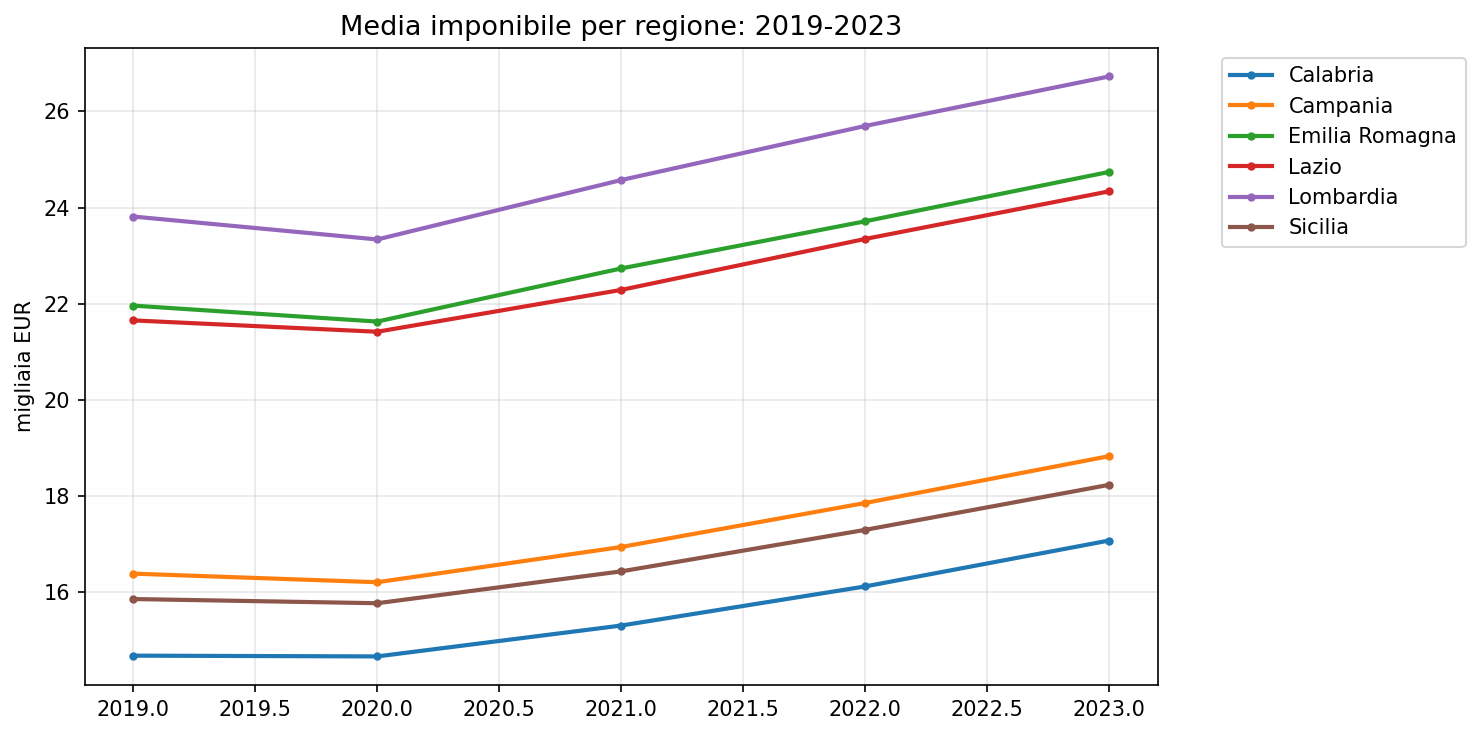

Salvato: figures/irpef_trend_regioni.png


In [6]:
# 3. Trend regioni 2019-2023 (top e bottom)
trend_regioni = con.execute(f"""
    SELECT anno_di_imposta AS anno, regione,
           ROUND(CAST(SUM(reddito_imponibile_eur) AS DOUBLE)
                 / NULLIF(CAST(SUM(numero_contribuenti) AS DOUBLE), 0), 0) AS media_imponibile
    FROM read_parquet('{GCS}')
    WHERE regione IN ('Lombardia', 'Emilia Romagna', 'Lazio', 'Campania', 'Sicilia', 'Calabria')
    GROUP BY anno_di_imposta, regione
    ORDER BY anno_di_imposta, regione
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
for reg in trend_regioni['regione'].unique():
    df_r = trend_regioni[trend_regioni['regione'] == reg]
    ax.plot(df_r['anno'], df_r['media_imponibile'] / 1000, marker='.', label=reg, linewidth=2)

ax.set_title('Media imponibile per regione: 2019-2023', fontsize=13)
ax.set_ylabel('migliaia EUR')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/irpef_trend_regioni.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/irpef_trend_regioni.png')


In [7]:
# 4. Grandi comuni (>200k contribuenti)
comuni = con.execute(f"""
    SELECT denominazione_comune AS comune, regione,
           CAST(numero_contribuenti AS BIGINT) AS contribuenti,
           CAST(reddito_imponibile_eur AS BIGINT) AS imponibile,
           ROUND(CAST(reddito_imponibile_eur AS DOUBLE)
                 / NULLIF(CAST(numero_contribuenti AS DOUBLE), 0), 0) AS media_imponibile
    FROM read_parquet('{GCS}')
    WHERE anno_di_imposta = 2023 AND CAST(numero_contribuenti AS BIGINT) >= 200000 AND regione != 'Mancante/errata'
    ORDER BY media_imponibile DESC
""").fetchdf()

display(comuni)

print(f"I comuni con oltre 200.000 contribuenti: {len(comuni)}")
print(f"Milano: {int(comuni[comuni['comune']=='MILANO']['media_imponibile'].values[0]):,} EUR")
print(f"Roma:   {int(comuni[comuni['comune']=='ROMA']['media_imponibile'].values[0]):,} EUR")
print(f"Napoli: {int(comuni[comuni['comune']=='NAPOLI']['media_imponibile'].values[0]):,} EUR")


,comune,regione,contribuenti,imponibile,media_imponibile
0,MILANO,Lombardia,1047822,38149599569,"36,408"
1,BOLOGNA,Emilia Romagna,308995,8823064967,"28,554"
2,ROMA,Lazio,1982316,55910083326,"28,204"
3,FIRENZE,Toscana,283661,7717146848,"27,206"
4,VERONA,Veneto,201073,5282284055,"26,270"
5,TORINO,Piemonte,641387,16770892227,"26,148"
6,GENOVA,Liguria,469790,11553479507,"24,593"
7,BARI,Puglia,218565,5101285924,"23,340"
8,NAPOLI,Campania,505838,11098320952,"21,940"
9,PALERMO,Sicilia,367930,7998813165,"21,740"


I comuni con oltre 200.000 contribuenti: 10
Milano: 36,408 EUR
Roma:   28,204 EUR
Napoli: 21,940 EUR


In [8]:
# 5. Distribuzione per scaglione di reddito (2023, nazionale)
scaglioni = con.execute(f"""
    SELECT
           CAST(SUM(reddito_complessivo_minore_o_uguale_a_zero_euro_freq) AS BIGINT) AS n_zero,
           CAST(SUM(reddito_complessivo_da_0_a_10000_euro_freq) AS BIGINT) AS n_0_10k,
           CAST(SUM(reddito_complessivo_da_10000_a_15000_euro_freq) AS BIGINT) AS n_10_15k,
           CAST(SUM(reddito_complessivo_da_15000_a_26000_euro_freq) AS BIGINT) AS n_15_26k,
           CAST(SUM(reddito_complessivo_da_26000_a_55000_euro_freq) AS BIGINT) AS n_26_55k,
           CAST(SUM(reddito_complessivo_da_55000_a_75000_euro_freq) AS BIGINT) AS n_55_75k,
           CAST(SUM(reddito_complessivo_da_75000_a_120000_euro_freq) AS BIGINT) AS n_75_120k,
           CAST(SUM(reddito_complessivo_oltre_120000_euro_freq) AS BIGINT) AS n_120k_plus
    FROM read_parquet('{GCS}')
    WHERE anno_di_imposta = 2023
""").fetchdf()

# Reshape per grafico
scat = scaglioni.T.reset_index()
scat.columns = ['scaglione', 'contribuenti']
scat['pct'] = scat['contribuenti'] / scat['contribuenti'].sum() * 100
display(scat)
print(f"Contribuenti sotto 15.000 EUR: {scat.loc[0:2, 'contribuenti'].sum():,} ({scat.loc[0:2, 'pct'].sum():.0f}%)")
print(f"Contribuenti sopra 55.000 EUR: {scat.loc[5:7, 'contribuenti'].sum():,} ({scat.loc[5:7, 'pct'].sum():.0f}%)")


,scaglione,contribuenti,pct
0,n_zero,1743,0
1,n_0_10k,10133315,25
2,n_10_15k,4848795,12
3,n_15_26k,11906007,29
4,n_26_55k,12013458,29
5,n_55_75k,1136706,3
6,n_75_120k,865075,2
7,n_120k_plus,350356,1


Contribuenti sotto 15.000 EUR: 14,983,853 (36%)
Contribuenti sopra 55.000 EUR: 2,352,137 (6%)


In [10]:
con.close()
print("Completato.")


Completato.
